In [1]:
import torch
from cryosim.icemaker import Icemaker, rfftn
from cryosim.plotting_tools import plot3d
from cryosim.array_utils import soft_voxelize_coordinates
from cryosim.fft_tools import fft3
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
from torch.autograd import Variable
from math import exp


def gaussian(window_size, sigma):
    gauss = torch.Tensor(
        [
            exp(-((x - window_size // 2) ** 2) / float(2 * sigma**2))
            for x in range(window_size)
        ]
    )
    return gauss / gauss.sum()


def create_window(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = Variable(
        _2D_window.expand(channel, 1, window_size, window_size).contiguous()
    )
    return window


def create_window_3D(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t())
    _3D_window = (
        _1D_window.mm(_2D_window.reshape(1, -1))
        .reshape(window_size, window_size, window_size)
        .float()
        .unsqueeze(0)
        .unsqueeze(0)
    )
    window = Variable(
        _3D_window.expand(
            channel, 1, window_size, window_size, window_size
        ).contiguous()
    )
    return window


def _ssim(img1, img2, window, window_size, channel, size_average=True):
    mu1 = F.conv2d(img1, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size // 2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = (
        F.conv2d(img1 * img1, window, padding=window_size // 2, groups=channel) - mu1_sq
    )
    sigma2_sq = (
        F.conv2d(img2 * img2, window, padding=window_size // 2, groups=channel) - mu2_sq
    )
    sigma12 = (
        F.conv2d(img1 * img2, window, padding=window_size // 2, groups=channel)
        - mu1_mu2
    )

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    )

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)


def _ssim_3D(img1, img2, window, window_size, channel, size_average=True):
    mu1 = F.conv3d(img1, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv3d(img2, window, padding=window_size // 2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)

    mu1_mu2 = mu1 * mu2

    sigma1_sq = (
        F.conv3d(img1 * img1, window, padding=window_size // 2, groups=channel) - mu1_sq
    )
    sigma2_sq = (
        F.conv3d(img2 * img2, window, padding=window_size // 2, groups=channel) - mu2_sq
    )
    sigma12 = (
        F.conv3d(img1 * img2, window, padding=window_size // 2, groups=channel)
        - mu1_mu2
    )

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    )

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)


class SSIM(torch.nn.Module):
    def __init__(self, window_size=11, size_average=True):
        super(SSIM, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = create_window(window_size, self.channel)

    def forward(self, img1, img2):
        (_, channel, _, _) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = create_window(self.window_size, channel)

            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)

            self.window = window
            self.channel = channel

        return _ssim(img1, img2, window, self.window_size, channel, self.size_average)


class SSIM3D(torch.nn.Module):
    def __init__(self, window_size=11, size_average=True):
        super(SSIM3D, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = create_window_3D(window_size, self.channel)

    def forward(self, img1, img2):
        (_, channel, _, _, _) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = create_window_3D(self.window_size, channel)

            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)

            self.window = window
            self.channel = channel


def ssim(img1, img2, window_size=11, size_average=True):
    (_, channel, _, _) = img1.size()
    window = create_window(window_size, channel)

    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)

    return _ssim(img1, img2, window, window_size, channel, size_average)


def ssim3D(img1, img2, window_size=11, size_average=True):
    (_, channel, _, _, _) = img1.size()
    window = create_window_3D(window_size, channel)

    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)

    return _ssim_3D(img1, img2, window, window_size, channel, size_average)

In [3]:
nx = ny = nz = 200
dx = 0.25
im = Icemaker(dx, nx, nz)

In [4]:
original_ice = im.generate_ice()

Output()

In [5]:
N = im.n_ice_molecules_theory
x_init = (torch.rand(N) - 0.5) * nx * dx
y_init = (torch.rand(N) - 0.5) * ny * dx
z_init = (torch.rand(N) - 0.5) * nz * dx
coords = torch.stack([x_init, y_init, z_init], dim=1)
coords.shape

torch.Size([3927, 3])

In [6]:
ice_init = soft_voxelize_coordinates(coords, (nz, ny, nx), dx)

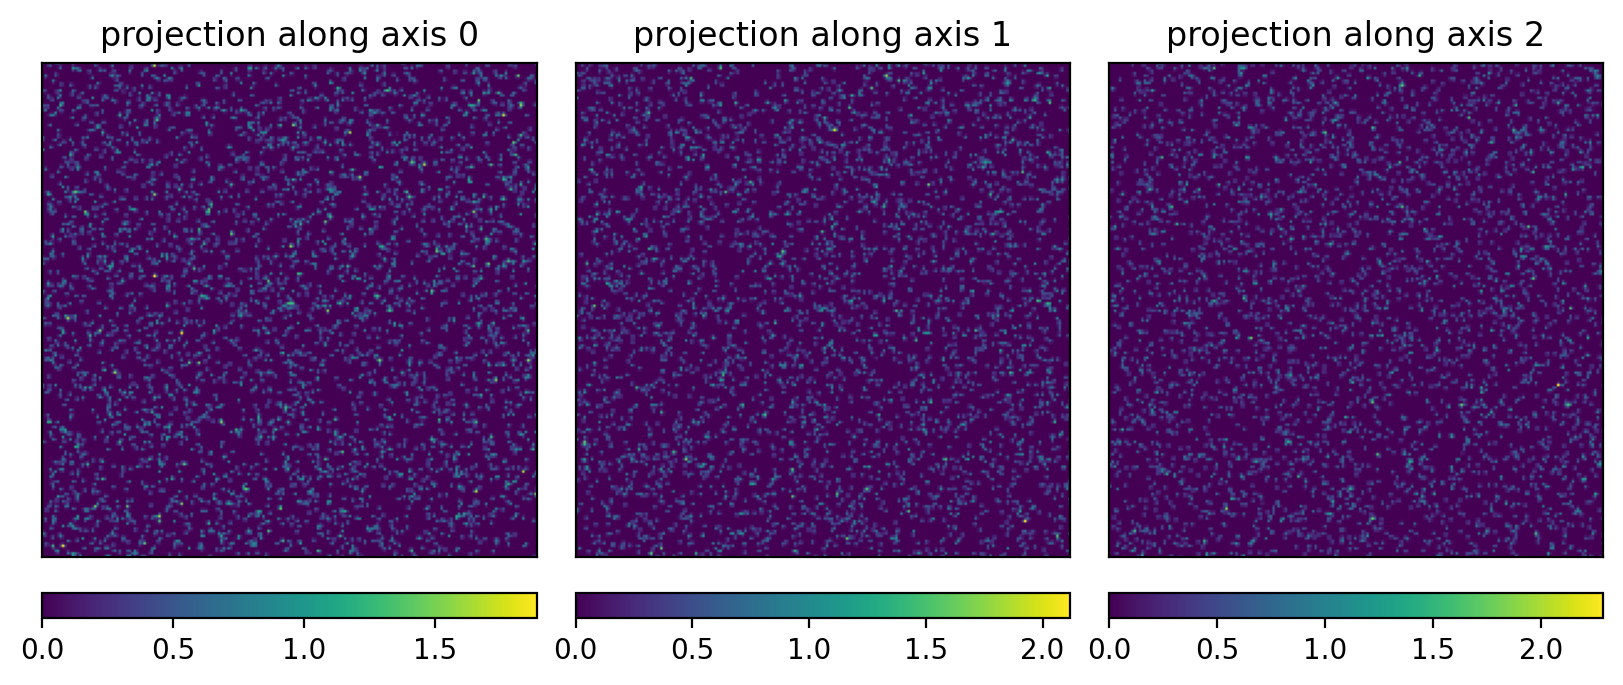

In [7]:
plot3d(ice_init)

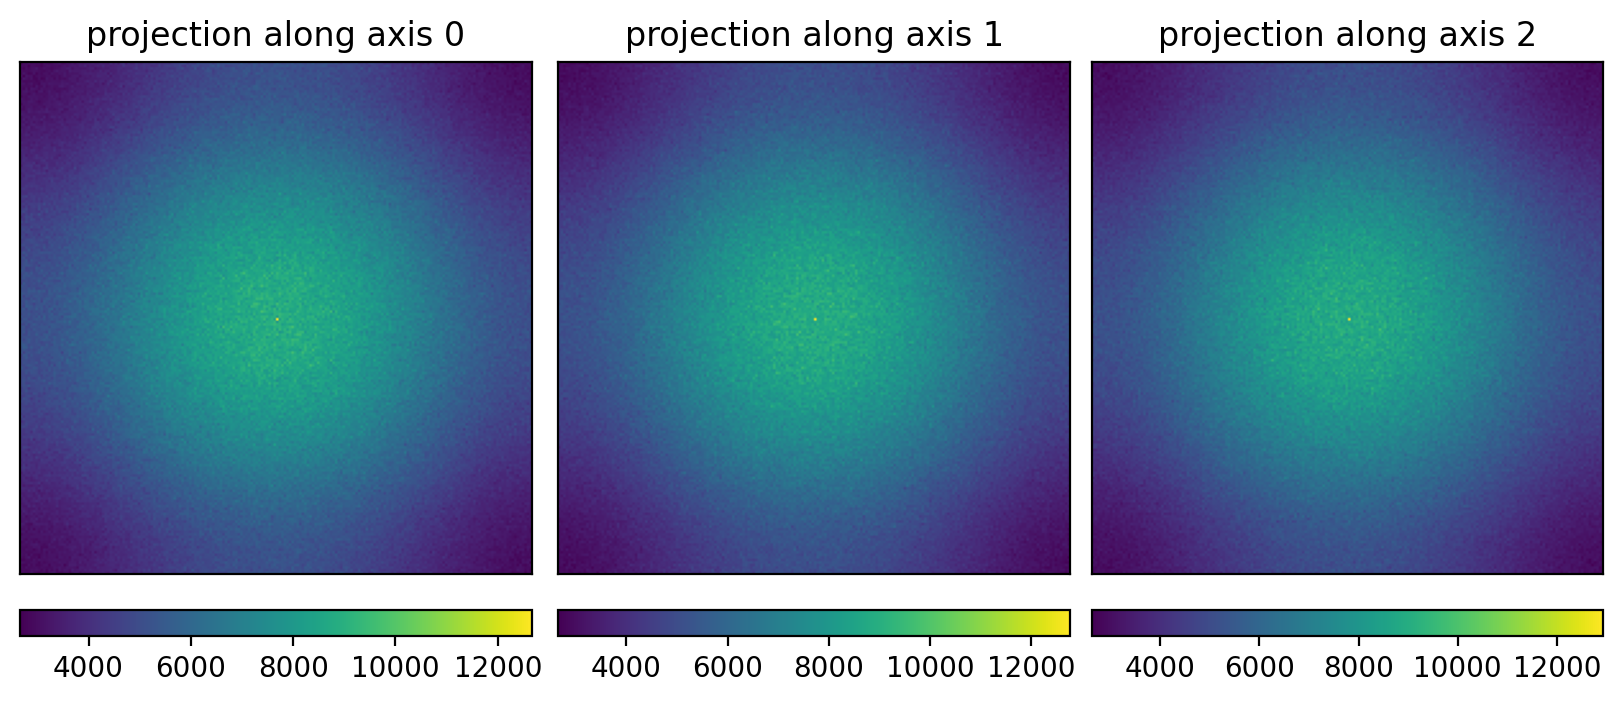

In [8]:
plot3d(torch.abs(fft3(ice_init)))

## Gradient

In [17]:
import torch


def gaussian_kernel_3d(kernel_size: int, sigma: float, device="cpu"):
    """Create a 3D Gaussian kernel."""
    coords = torch.arange(kernel_size, device=device) - kernel_size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = g / g.sum()

    # Outer product to get 3D kernel
    g3 = g[:, None, None] * g[None, :, None] * g[None, None, :]
    return g3


def ssim3d(
    x: torch.Tensor,
    y: torch.Tensor,
    window_size: int = 11,
    sigma: float = 1.5,
    data_range: float = 1.0,
    K1: float = 0.01,
    K2: float = 0.03,
    eps: float = 1e-8,
):
    """
    Computes SSIM for 3D volumes (B, C, D, H, W) in pure PyTorch.

    Args:
        x, y      : input volumes with same shape
        window_size : size of Gaussian kernel
        sigma     : std of Gaussian kernel
        data_range: maximum intensity (e.g., 1.0 or 255)
    Returns:
        SSIM value (scalar tensor)
    """
    device = x.device
    B, C, D, H, W = x.shape

    # Gaussian smoothing kernel
    kernel = gaussian_kernel_3d(window_size, sigma, device=device)
    kernel = kernel.expand(C, 1, -1, -1, -1)  # shape (C,1,K,K,K)

    # Apply Gaussian filter using conv3d
    mu_x = F.conv3d(x, kernel, padding=window_size // 2, groups=C)
    mu_y = F.conv3d(y, kernel, padding=window_size // 2, groups=C)

    mu_x2 = mu_x * mu_x
    mu_y2 = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x2 = F.conv3d(x * x, kernel, padding=window_size // 2, groups=C) - mu_x2
    sigma_y2 = F.conv3d(y * y, kernel, padding=window_size // 2, groups=C) - mu_y2
    sigma_xy = F.conv3d(x * y, kernel, padding=window_size // 2, groups=C) - mu_xy

    # SSIM constants
    C1 = (K1 * data_range) ** 2
    C2 = (K2 * data_range) ** 2

    # SSIM formula
    num = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
    den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)

    ssim_map = num / (den + eps)

    # Return mean over all dimensions
    return ssim_map.mean()


def optimize_coordinates(
    init_coords, target_fft_amp, lr=1e-2, iters=1000, device="cuda"
):
    """
    Gradient-descent optimization of coordinates so that
    | FFT( voxelized(coords) ) | matches target_fft_amp.

    Args:
        init_coords      : (N,3) float tensor
        target_fft_amp   : (Dx, Dy, Dz) known magnitude of FFT
        soft_voxelize_coordinates : function mapping coords -> 3D grid
        lr               : learning rate
        iters            : number of iterations
        device           : cuda/cpu

    Returns:
        optimized_coords : (N,3) updated coordinates
        loss_log         : list of losses
    """

    coords = init_coords.clone().to(device).requires_grad_(True)
    target_fft_amp = target_fft_amp.to(device)

    optimizer = torch.optim.Adam([coords], lr=lr)
    loss_log = []

    # Precompute DC index
    dc_x = target_fft_amp.shape[0] // 2
    dc_y = target_fft_amp.shape[1] // 2
    dc_z = 0

    for it in tqdm(range(iters)):
        optimizer.zero_grad()

        # 1. Voxelize the coordinates
        grid = soft_voxelize_coordinates(coords, (nz, ny, nx), dx)  # shape (Dx, Dy, Dz)

        # 2. FFT
        Fgrid = rfftn(grid)

        # 3. Magnitude
        amp = torch.abs(Fgrid)

        # 4. Zero out the DC component (ignore in loss)
        #    (you can also match DC separately if you want)
        amp_dc_ignored = amp.clone()
        amp_dc_ignored[dc_x, dc_y, dc_z] = 0

        target_dc_ignored = target_fft_amp.clone()
        target_dc_ignored[dc_x, dc_y, dc_z] = 0

        # 5. Loss: L2 between amplitudes
        # loss = F.l1_loss(amp_dc_ignored, target_dc_ignored)
        loss = 1 - ssim3D(
            amp_dc_ignored[None, None, ...], target_dc_ignored[None, None, ...]
        )

        # 6. Backprop
        loss.backward()
        optimizer.step()

        loss_log.append(float(loss))
    return coords.detach().cpu(), grid.detach().cpu(), loss_log, amp.detach().cpu()

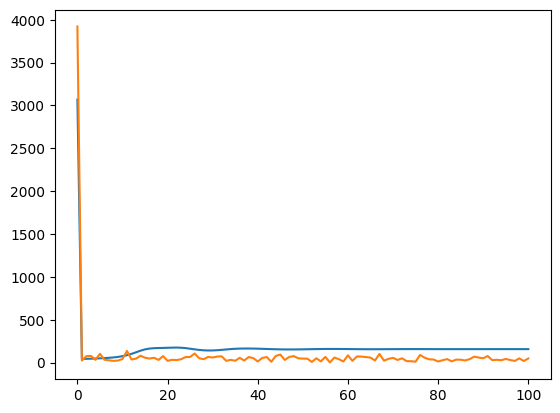

In [21]:
plt.plot(im.interp_f_halfkernel[100, 100, :])

In [18]:
coords_opt, ice, losses, amp = optimize_coordinates(
    init_coords=coords,
    target_fft_amp=im.interp_f_halfkernel,
    lr=1e-1,
    iters=50,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:13<00:00,  3.75it/s]


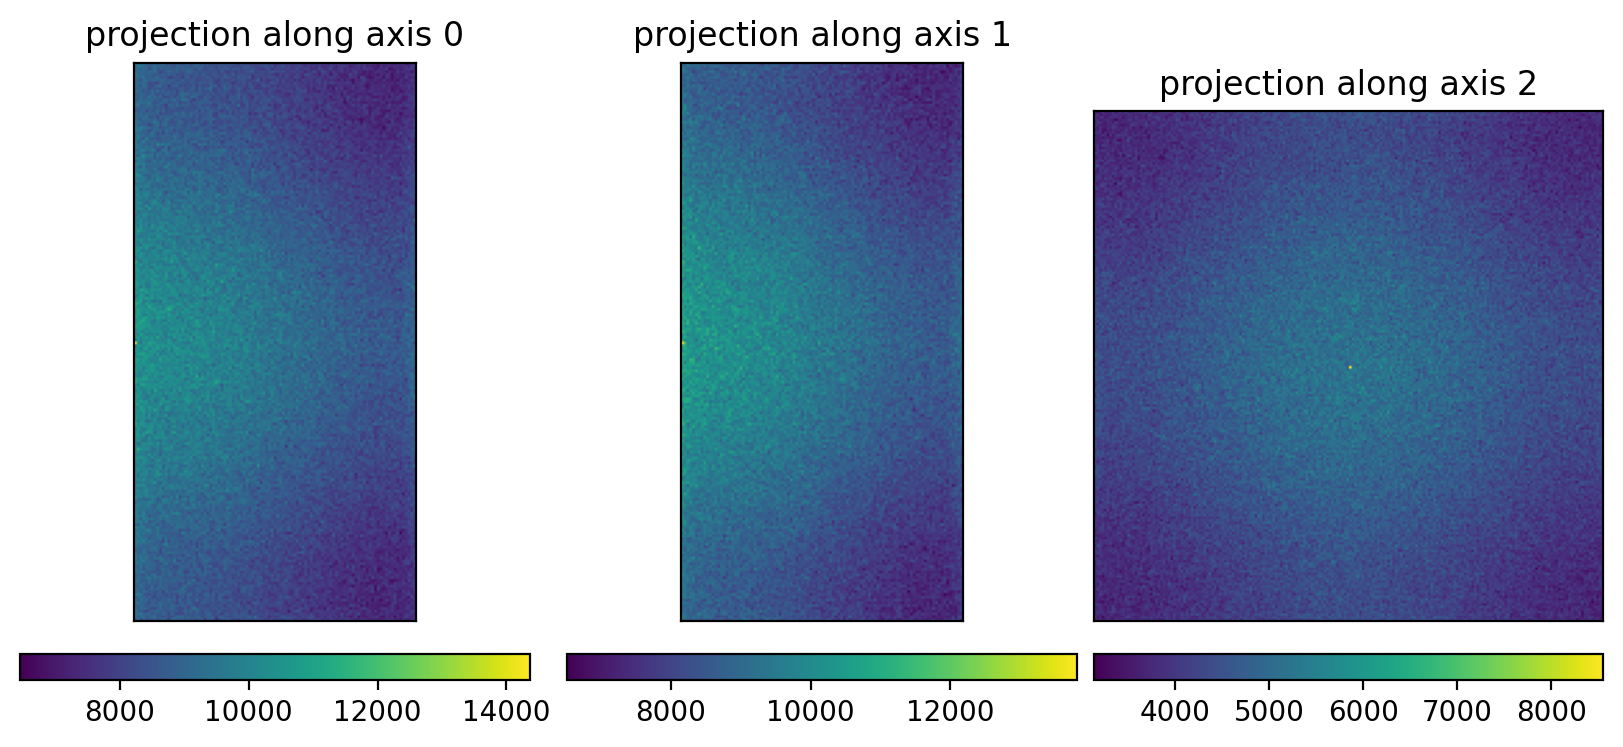

In [19]:
plot3d(amp)

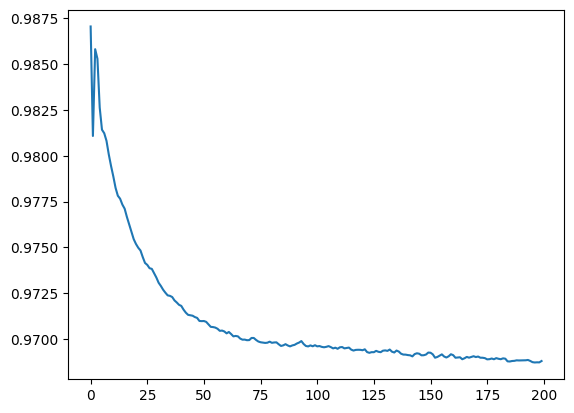

In [11]:
plt.plot(losses)

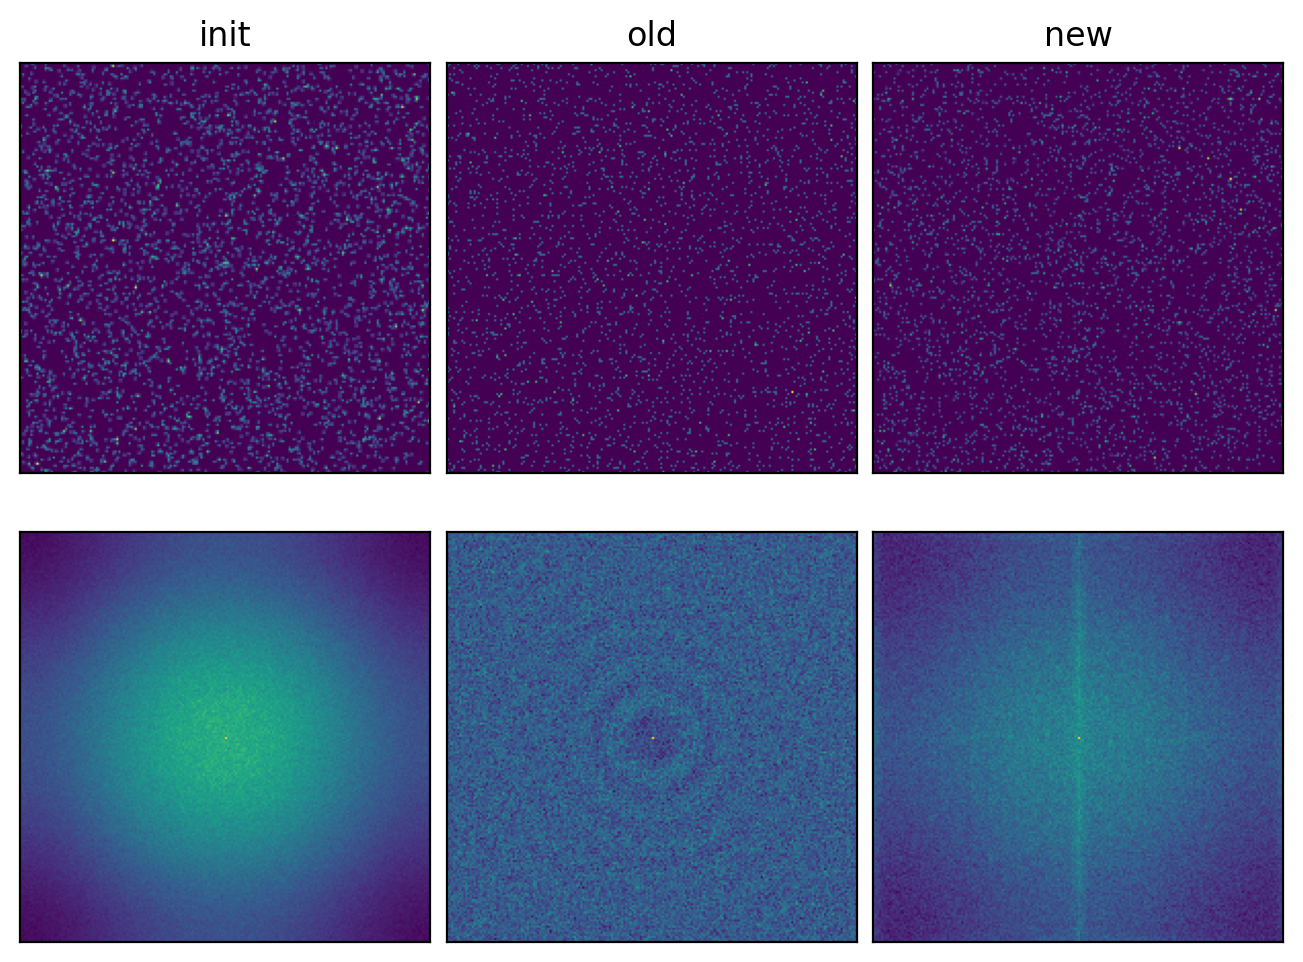

In [12]:
fig, axes = plt.subplots(2, 3, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
vols = [ice_init, im.current_icedeltas[0].cpu().detach(), ice]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(vols[i].sum(0))

    ax = axes[1, i]
    ax.imshow(torch.abs(fft3(vols[i])).sum(0))
axes[0, 0].set_title("init")
axes[0, 1].set_title("old")
axes[0, 2].set_title("new")
plt.show()